# TP 4 Solutions

In [53]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd
import os
import random
import math
import cmath

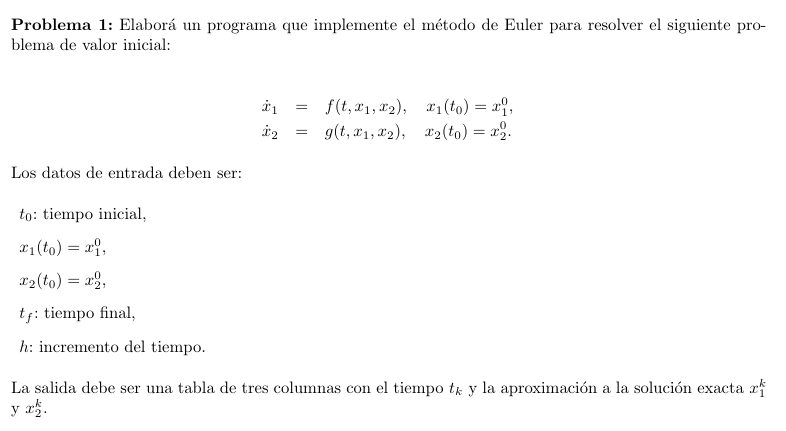

In [2]:
# Define Euler Solver in Python
def euler_solver_2d(f1, f2, t0, tf, x10, x20, h):

    # Define steps
    steps = int((tf-t0)/h)

    # Initialize variables
    x1 = x10
    x2 = x20
    t = t0

    t_list = [t]
    x1_list = [x1]
    x2_list = [x2]


    # For loop
    for i in range(steps-1):

        x1_old = x1
        x2_old = x2

        x1 = x1_old + h*f1(t, x1_old, x2_old)
        x2 = x2_old + h*f2(t, x1_old, x2_old)
        t = t + h

        t_list.append(t)
        x1_list.append(x1)
        x2_list.append(x2)

    return np.array(t_list), np.array(x1_list), np.array(x2_list)

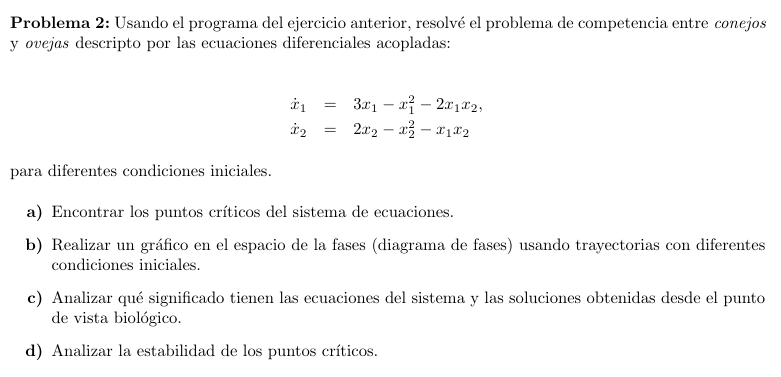

**a) Puntos críticos**

Se han obtenido los siguientes puntos críticos de forma analítica

$\hat{x}_{1}: (0, 0)$ <br>
$\hat{x}_{2}: (0, 2)$ <br>
$\hat{x}_{3}: (3, 0)$ <br>
$\hat{x}_{4}: (1, 1)$

In [7]:
# Store critical points
list_cp_all = [(0, 0),
           (0, 2),
           (3, 0),
           (1, 1)]

list_cp = [(0, 0),
           (0, 2)]

In [44]:
# Define funtions f(x1, x2) & g(x1, x2)
def f_edo(t, x1, x2):
    return 3*x1-x1**2-2*x1*x2

def g_edo(t, x1, x2):
    return 2*x2-x2**2-x1*x2

# Initialize parameters
T0 = 0
TF = 20
#deltaXs = 1
H = 0.01

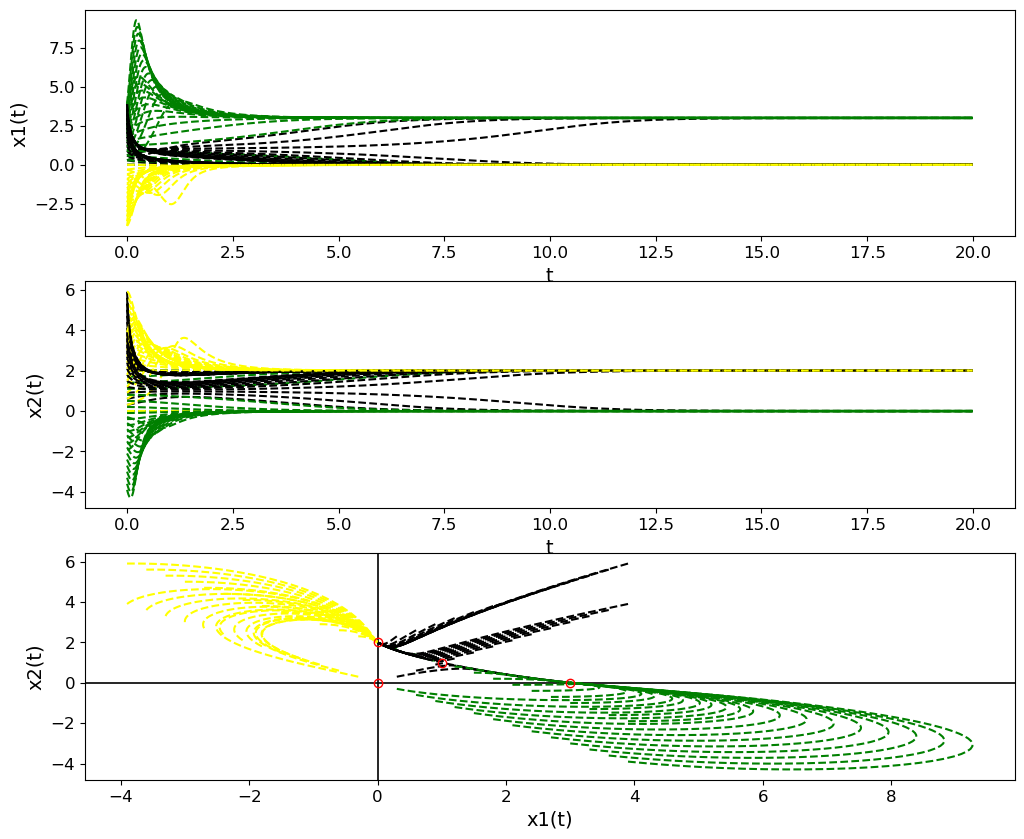

In [78]:
# Plot euler solver results (X, Y phases map)
fig, ax = plt.subplots(3, 1, figsize=(12, 10))

ax[2].axhline(0, color='black', linewidth=1.2)
ax[2].axvline(0, color='black', linewidth=1.2)

for delta in np.arange(0, 4, 0.3):
    for lcp in list_cp:
        
        t, x1, x2 = euler_solver_2d(f_edo, g_edo, 
                                    T0, TF, 
                                    lcp[0]+delta, lcp[1]+delta, 
                                    H)
    
        ax[2].plot(x1, x2, '--', color = 'black')
        ax[0].plot(t, x1, '--', color = 'black')
        ax[1].plot(t, x2, '--', color = 'black')

        t, x1, x2 = euler_solver_2d(f_edo, g_edo, 
                                    T0, TF, 
                                    lcp[0]+delta, lcp[1]-delta, 
                                    H)
    
        ax[2].plot(x1, x2, '--', color = 'green')
        ax[0].plot(t, x1, '--', color = 'green')
        ax[1].plot(t, x2, '--', color = 'green')

        t, x1, x2 = euler_solver_2d(f_edo, g_edo, 
                                    T0, TF, 
                                    lcp[0]-delta, lcp[1]+delta, 
                                    H)
    
        ax[2].plot(x1, x2, '--', color = 'yellow')
        ax[0].plot(t, x1, '--', color = 'yellow')
        ax[1].plot(t, x2, '--', color = 'yellow')

for cp in list_cp_all:
    ax[2].plot(cp[0], cp[1], marker='o', mfc='none', mec='red')


ax[0].set_ylabel(r'x1(t)', fontsize = 14)
ax[0].tick_params(axis='y', labelsize=12) 
ax[0].set_xlabel(r't', fontsize = 14)
ax[0].tick_params(axis='x', labelsize=12)

ax[1].set_ylabel(r'x2(t)', fontsize = 14)
ax[1].tick_params(axis='y', labelsize=12) 
ax[1].set_xlabel(r't', fontsize = 14)
ax[1].tick_params(axis='x', labelsize=12)

ax[2].set_ylabel(r'x2(t)', fontsize = 14)
ax[2].tick_params(axis='y', labelsize=12) 
ax[2].set_xlabel(r'x1(t)', fontsize = 14)
ax[2].tick_params(axis='x', labelsize=12)

**c) --**

**d) Evaluación de puntos críticos**

In [79]:
# Define jacobian Matrix function
def jac_max_2d(df_dx, df_dy, dg_dx, dg_dy, x_cp, y_cp):

    a = df_dx(x_cp, y_cp)
    b = df_dy(x_cp, y_cp)
    c = dg_dx(x_cp, y_cp)
    d = dg_dy(x_cp, y_cp)

    return a, b, c, d

# Define Bhaskara solver to get eigenvalues
def get_eigenval(df_dx, df_dy, dg_dx, dg_dy, x_cp, y_cp):

    a, b, c, d = jac_max_2d(df_dx, df_dy, dg_dx, dg_dy, x_cp, y_cp)
    #print(a, b, c, d)

    bhask_a = 1
    bhask_b = (-1)*(a + d)
    bhask_c = (a*d-b*c)

    eigV1 = ((-bhask_b) + cmath.sqrt(bhask_b**2-4*bhask_a*bhask_c))/(2*bhask_a)
    eigV2 = ((-bhask_b) - cmath.sqrt(bhask_b**2-4*bhask_a*bhask_c))/(2*bhask_a)

    return eigV1, eigV2

# Define critical point stabilizity function
def cp_stab(df_dx, df_dy, dg_dx, dg_dy, x_cp, y_cp):

    # Gen eigenvalues result
    eigV1, eigV2 = get_eigenval(df_dx, df_dy, dg_dx, dg_dy, x_cp, y_cp)

    # Print critical point
    print(f'X*: {x_cp}; Y*: {y_cp}')

    # Print eigenvalues
    print(f'Lambda1: {eigV1}; Lambda2: {eigV2}')

    if eigV1.imag != 0 or eigV2.imag != 0: # Check if eigenvalues has an imaginary component

        if abs(eigV1.real) < 1e-12 and abs(eigV2.real) < 1e-12: # No real component
            print('Centro. Estable')

        elif eigV1.real > 0:
            print('Punto espiral. Inestable')

        else:
            print('Punto espiral. Asintóticamente estable')

    else: # Eigenvalues with no imaginary component

        eigV1 = eigV1.real
        eigV2 = eigV2.real

        if eigV1 > 0 and eigV2 > 0: # Positive values

            if eigV1 == eigV2:
                print('Nodo propio/Impropio. Inestable')

            else: # eigV1 > eigV2 or eigV1 < eigV2
                print('Nodo impropio. Inestable')

        elif eigV1 < 0 and eigV2 < 0:

            if eigV1 == eigV2:
                print('Nodo propio/Impropio. Asintóticamente estable')

            else: # eigV1 > eigV2 or eigV1 < eigV2
                print('Nodo impropio. Asintóticamente estable')

        elif eigV1 * eigV2 < 0:
            print('Punto silla. Inestable')


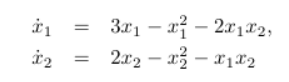

In [80]:
# Define df/dx, df/dy, dg/dx & dg/dy
## df/dt
def df_dx(x, y):
    return 3 - 2*x - 2*y

def df_dy(x, y):
    return -2*x

## dg/dt
def dg_dx(x, y):
    return -y

def dg_dy(x, y):
    return 2 - 2*y - x

In [82]:
import critPintStab as cp_stab

ModuleNotFoundError: No module named 'critPintStab'

In [81]:
for cp in list_cp_all:
    #print(cp)
    cp_stab(df_dx, df_dy, dg_dx, dg_dy, cp[0], cp[1])

X*: 0; Y*: 0
Lambda1: (3+0j); Lambda2: (2+0j)
Nodo impropio. Inestable
X*: 0; Y*: 2
Lambda1: (-1+0j); Lambda2: (-2+0j)
Nodo impropio. Asintóticamente estable
X*: 3; Y*: 0
Lambda1: (-1+0j); Lambda2: (-3+0j)
Nodo impropio. Asintóticamente estable
X*: 1; Y*: 1
Lambda1: (0.41421356237309515+0j); Lambda2: (-2.414213562373095+0j)
Punto silla. Inestable


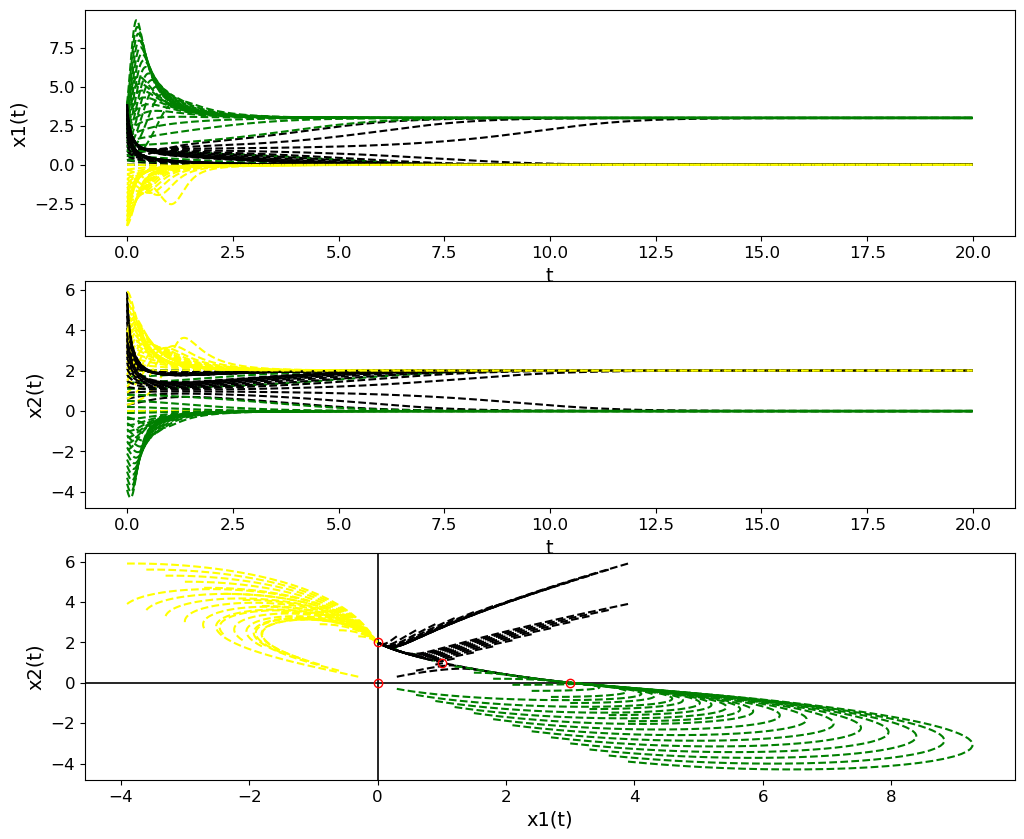

# Define jacobian Matrix functio
